In [4]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
gapmoe_model = gapmoe(rhos_path="../test_data/hist_D.dat",mass_path="../test_data/hist_M.dat",mu_path="../test_data/hist_murel.dat")
gapmoe_model.set_data()

JD0 = 2450000

In [5]:
tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

In [6]:
def mag2flux(mag):
    return 10**(-mag / 2.5)

def flux2mag(flux):
    return -2.5 * np.log10(flux)

def linear_fit(x,y,w):
    w_sum = np.sum(w)
    wxy_sum = np.sum(w*x*y)
    wx_sum = np.sum(w*x)
    wy_sum = np.sum(w*y)
    wxx_sum = np.sum(w*x*x)
    bunbo = w_sum*wxx_sum-wx_sum**2
    a = (w_sum*wxy_sum-wx_sum*wy_sum)/bunbo
    b = (wxx_sum*wy_sum-wx_sum*wxy_sum)/bunbo
    y_fit = a * x + b
    chi2 = np.sum(w * (y - y_fit) ** 2)
    return a,b,chi2

cVIBoya = 0.50141358
dVIBoya = 0.41968496
EVI, AI = 1.483,  1.822
def calc_thS(_fs_I,_fs_v):
    I_S = flux2mag(_fs_I)
    V_S = flux2mag(_fs_v)
    VI_S = V_S - I_S
    
    I0_S = I_S - AI
    VI0_S = VI_S - EVI
    
    _theta_star  = 0.5*10**(cVIBoya + dVIBoya*VI0_S  - 0.2*I0_S)
    return _theta_star

In [7]:
loaded = np.load("../simu_data/simu_data_01.npz", allow_pickle=True)

simu_data = {k: loaded[k] for k in loaded.files}

Is = 18 + AI
Vs = 1 + 18 + EVI
fs_I = mag2flux(Is)
fs_V = mag2flux(Vs)

tE = 47.1147
rho = 0.000528216
s = 1.22626
piEN = 0.0565383
piEE = 0.0565382
gamma1 = 0.000702119
gamma2 = 0.00175531
gamma3 = 0.0017553

t0 = 10090 - 5       
u0 = 0.01          
q = 0.001
alpha = np.pi/2 + 1

init_params = np.array([t0,tE,u0,q,s,alpha,rho,piEN,piEE,gamma1,gamma2,gamma3])
pr = [math.log(s), math.log(q), u0, alpha, math.log(rho), math.log(tE), t0+JD0, piEN, piEE, gamma1,gamma2,gamma3]

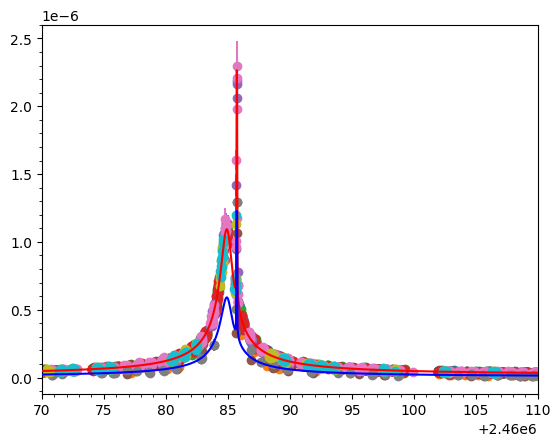

In [8]:
t_plot = np.linspace(t0-tE+JD0,t0+tE+JD0,10000)
amp_plot = np.array(VBM.BinaryLightCurveOrbital(pr, t_plot)[0])
mag_plot_I = amp_plot * fs_I + mag2flux(20)
mag_plot_V = amp_plot * fs_V + mag2flux(22)
plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["flux_obs"], simu_data[name]["ferr"],fmt="o") 

plt.xlim(JD0+10070,JD0+10110)
plt.minorticks_on()

plt.show()

In [12]:
kappa = 8.144; #mas /MO
G = 2.959122082855911e-4 
@jit
def calc_physical_params(x,thS):
    tE, rho, s, piEN, piEE, gamma1, gamma2, gamma3 = x
    piE = jnp.sqrt(piEE**2 + piEN**2)
    
    thE = thS / rho
    ML = thE / kappa / piE
    murel = thE / tE * 365.25
    murel_E = murel * piEE / piE
    murel_N = murel * piEN / piE

    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_parallel = jnp.sqrt(gamma1**2 + gamma3**2)
    gamma_ratio = gamma_parallel / gamma3
    orbital_scale = jnp.cbrt((s**3) * gamma_sq * gamma_ratio / (ML * G))
    gamma_abs = jnp.sqrt(gamma_sq)
    Ds = 1 / ((orbital_scale - piE) * thE)

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L

    RE = DL * thE
    orbital_radi = RE * s * gamma_parallel / gamma3

    cosi = gamma3 * gamma2 / (gamma_parallel * gamma_abs)
    tanphi = - gamma1 * gamma_abs / (gamma3 * gamma_parallel)

    return jnp.array([murel_E, murel_N, ML, DL, Ds, orbital_radi, cosi, tanphi])

@jit
def calc_ln_det_jacobian(x, thS):
    J = jacfwd(calc_physical_params)(x, thS)
    _, lndet = jnp.linalg.slogdet(J)
    return lndet

In [19]:
physical_use_ind = np.array([1,6,4,7,8,9,10,11])

def calc_ln_like(theta,source_flux=False):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _piEN, _piEE,_gamma1, _gamma2, _gamma3 = theta[7],theta[8],theta[9],theta[10],theta[11]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0, _piEN, _piEE, _gamma1,_gamma2,_gamma3]

    _chi2_sum = 0
    for _name in simu_data.keys():
        _model_amp = np.array(VBM.BinaryLightCurveOrbital(_pr,simu_data[_name]["time"]+JD0)[0])
        _fs,_fb,_chi2 = linear_fit(_model_amp,simu_data[_name]["flux_obs"],simu_data[_name]["ferr"]**(-2))
        _chi2_sum += _chi2
        if _name == 'MOA_Red':
            _fs_i = _fs
        if _name == 'MOA_V':
            _fs_v = _fs

    if source_flux:
        return -0.5*_chi2_sum, _fs_i, _fs_v
    else:
        return -0.5*_chi2_sum
    
def calc_ln_prior_gal(x, thS):
    murel_E, murel_N, ML, DL, DS, orbital_radi, cosi, tanphi = calc_physical_params(x, thS)
    mu_abs = jnp.sqrt(murel_E**2 + murel_N**2)
    mu_phi = jnp.arctan2(murel_E,murel_N)
    DL *= 1e3
    DS *= 1e3
    
    if not (gapmoe_model.M_MIN <= ML <= gapmoe_model.M_MAX):
        return -np.inf,-np.inf
    if not (gapmoe_model.DL_MIN <= DL < gapmoe_model.DL_MAX):
        return -np.inf,-np.inf
    if not (gapmoe_model.DS_MIN <= DS < gapmoe_model.DS_MAX):
        return -np.inf,-np.inf
    if DL >= DS:
        return -np.inf,-np.inf
    if not (gapmoe_model.MU_MIN <= mu_abs < gapmoe_model.MU_MAX):
        return -np.inf,-np.inf
    if (orbital_radi < 0.0) or (orbital_radi > 10000.0):
        return -np.inf,-np.inf
    
    return gapmoe_model.log_galactic_prior(ML, DL, DS, mu_abs, mu_phi),1/(1+tanphi**2) 

def check_positive(theta):
    _t0, _tE, _u0, _q, _s, _theta, _rho = theta[0], theta[1], theta[2], theta[3], theta[4], theta[5], theta[6]
    return _s > 0 and _q > 0 and _rho > 0 and _tE > 0

def ln_prob(theta):
    if not check_positive(theta):
        return -np.inf, np.nan
    _use_params = theta[physical_use_ind]
    _ln_like, _fs_i, _fs_v = calc_ln_like(theta,source_flux=True)
    _thS = calc_thS(_fs_i,_fs_v)
    _ln_det = calc_ln_det_jacobian(_use_params,_thS)
    _ln_prior_gal, _weight_tan = calc_ln_prior_gal(_use_params,_thS)
        
    if jnp.isneginf(_ln_like) or np.isneginf(_ln_det) or jnp.isneginf(_ln_prior_gal):
        return -jnp.inf, np.nan

    ln_post = _ln_like + _ln_prior_gal + _ln_det + np.log(_weight_tan)
    return ln_post, _thS

In [20]:
ln_prob(init_params)

(Array(-8766.467, dtype=float32), np.float64(0.00016740876457842783))

In [32]:
param_stds = [
    0.01,     # t0 [days]
    0.1,      # tE
    0.005,    # u0
    0.0001,    # q
    0.01,     # s
    0.05,     # alpha [rad]
    3e-4,     # rho
    0.00001,     # piEN
    0.00001,     # piEE
    3e-4,     # gamma1
    3e-4,     # gamma2
    3e-4      # gamma3
]

ndim = len(init_params)
nwalkers = 48

np.random.seed(45)
p0 = np.array([
    np.array(init_params) + np.random.normal(scale=param_stds)
    for _ in range(nwalkers)
])

In [33]:
for i, theta in enumerate(p0):
    lnpost, thS = ln_prob(theta)
    if not np.isfinite(lnpost):
        print(f"[{i}] 無効なサンプル（ln_post = -inf）")
        continue

    x_phys = theta[physical_use_ind]
    try:
        # 物理パラメータ計算
        murel_E, murel_N, ML, DL, DS, orbital_radi, cosi, tanphi = calc_physical_params(x_phys, thS)
        
        # 整形表示
        print(f"\n--- Walker {i} ---")
        print(f"μ_rel_E   = {murel_E:.6f}  # mas/yr")
        print(f"μ_rel_N   = {murel_N:.6f}  # mas/yr")
        print(f"M_L       = {ML:.6f}       # M_sun")
        print(f"D_L       = {DL:.6f}       # kpc")
        print(f"D_S       = {DS:.6f}       # kpc")
        print(f"R_orbit   = {orbital_radi:.6f}  # AU")
        print(f"cos(i)    = {cosi:.6f}")
        print(f"tan(φ)    = {tanphi:.6f}")
        print(f"thS       = {thS:.6f}       # μas")
        print(f"ln_post   = {lnpost:.3f}")
    except Exception as e:
        print(f"[{i}] 計算中にエラー: {e}")


--- Walker 0 ---
μ_rel_E   = 1.483780  # mas/yr
μ_rel_N   = 1.483450  # mas/yr
M_L       = 0.415878       # M_sun
D_L       = 7.450181       # kpc
D_S       = 8.883063       # kpc
R_orbit   = 2.777860  # AU
cos(i)    = 0.567541
tan(φ)    = -0.700629
thS       = 0.000167       # μas
ln_post   = -9822.258

--- Walker 1 ---
μ_rel_E   = 1.839102  # mas/yr
μ_rel_N   = 1.838800  # mas/yr
M_L       = 0.516152       # M_sun
D_L       = 7.179236       # kpc
D_S       = 8.894663       # kpc
R_orbit   = 2.968203  # AU
cos(i)    = 0.633549
tan(φ)    = -0.199425
thS       = 0.000165       # μas
ln_post   = -49956.395

--- Walker 2 ---
μ_rel_E   = 2.359026  # mas/yr
μ_rel_N   = 2.359293  # mas/yr
M_L       = 0.663327       # M_sun
D_L       = 5.091805       # kpc
D_S       = 6.177992       # kpc
R_orbit   = 3.050984  # AU
cos(i)    = 0.523377
tan(φ)    = -0.595045
thS       = 0.000167       # μas
ln_post   = -10037.803

--- Walker 3 ---
μ_rel_E   = 3.361100  # mas/yr
μ_rel_N   = 3.360996  # mas/yr



--- Walker 32 ---
μ_rel_E   = 1.653827  # mas/yr
μ_rel_N   = 1.653886  # mas/yr
M_L       = 0.463480       # M_sun
D_L       = 6.559740       # kpc
D_S       = 7.793132       # kpc
R_orbit   = 2.473405  # AU
cos(i)    = 0.621536
tan(φ)    = -0.240820
thS       = 0.000166       # μas
ln_post   = -13938.620

--- Walker 33 ---
μ_rel_E   = 1.863993  # mas/yr
μ_rel_N   = 1.864093  # mas/yr
M_L       = 0.520672       # M_sun
D_L       = 6.529414       # kpc
D_S       = 7.933719       # kpc
R_orbit   = 2.922877  # AU
cos(i)    = 0.634068
tan(φ)    = -0.566468
thS       = 0.000128       # μas
ln_post   = -13225.371

--- Walker 34 ---
μ_rel_E   = 0.917161  # mas/yr
μ_rel_N   = 0.917081  # mas/yr
M_L       = 0.256573       # M_sun
D_L       = 11.405508       # kpc
D_S       = 13.456234       # kpc
R_orbit   = 2.885241  # AU
cos(i)    = 0.463798
tan(φ)    = -0.884325
thS       = 0.000167       # μas
ln_post   = -14968.353
[35] 無効なサンプル（ln_post = -inf）

--- Walker 36 ---
μ_rel_E   = 1.067490  # ma